In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("pandas version:", pd.__version__)
#print("matplotlib.pyplot version:", plt.__version__)
print("seaborn version:", sns.__version__)

pandas version: 2.3.2
seaborn version: 0.13.2


This data is gathered from this website: https://www.rijdendetreinen.nl/en/open-data/train-archive

The data ranges from January 2019 till August 2025

### Data Dictionary

Below you will find the data dictionary provided by Rijden-de-treinen.

Each row in these files represent a stop at a station. Each service at least departs from and arrives at a station (i.e. two rows). For each stop, you can find the name of the station, the arrival and departure time, delays and cancellations. The exact meaning of each column is explained below.

The source for this data is the real-time data from NS with live departure times, live arrival times and service updates. This data is also used in the app and website of Rijden Treinen.

#### Columns
- `Service:RDT-ID` *Unique identifier (service):* This is the ID that Rijden de Treinen uses for this service. It has no useful meaning beyond uniquely identifying a single service on a single date. This ID will occur more than once in the CSV files because this ID is unique for each service. There is also a column Stop:RDT-ID with a unique ID for each stop.
- `Service:Date` *Service date (schedule date):* The scheduled service date for this service. The service date is not always the same as the actual date. For example, a service that departs at 23:59 on 31 July and arrives at 02:00 on 1 August has a service date of 31 July. Delays do not affect the service date.
- `Service:Type` *Service type:* The service type, for example: *Intercity*, *Sprinter* or *ICE International*.
- `Service:Company` *Operator:* Company operating this service, like NS or Arriva.
- `Service:Train number` *Train number:* The train number (service number) for this service uniquely identifies this service on this date. This number is sometimes also communicated to passengers (especially for international trains). A single service may sometimes have multiple train numbers. For example, when a train is split in two parts, or when a train changes a train number on a major station halfway.
- `Service:Completely cancelled` *Service is fully cancelled:* This column is true when all stops of this service have been cancelled. Or in other words: when the train does not run at all.
- `Service:Partly cancelled` *Partially cancelled:* This column is true when one or more stops of this service have been cancelled. Or in other words: when the train does not run on a part of the route.
- `Service:Maximum delay` *Highest delay for this service:* The highest delay (**in minutes**) of all stops of this service.
- `Stop:RDT-ID` *Unique identifier (stop):* Unique identifier for this stop. This ID is unique for each stop in the dataset. It has no further useful meaning.
- `Stop:Station code` *Station code:* Code (abbreviation) of the station name. See also the [dataset with railway stations.](https://www.rijdendetreinen.nl/en/open-data/stations)
- `Stop:Station name` *Station name:* The name of the station.
- `Stop:Arrival time` *Arrival time:* Scheduled arrival time in **RFC 3339 format.** This column is empty when no arrival was scheduled.
- `Stop:Arrival delay` *Arrival delay:* Arrival delay **in minutes.** This column is empty when no arrival was scheduled.
- `Stop:Arrival cancelled` *Cancelled arrival:* This column is true when the arrival at this stop has been cancelled. This column is empty when no arrival was scheduled.
- `Stop:Departure time` *Departure time:* Scheduled departure time in **RFC 3339 format.** This column is empty when no departure was scheduled.
- `Stop:Departure delay` *Departure delay:* Departure delay **in minutes.** This column is empty when no departure was scheduled.
- `Stop:Departure cancelled` *Cancelled departure:* This column is true when the departure at this stop has been cancelled. This column is empty when no departure was scheduled.
- `Stop:Platform change` *Platform change:* This column is true when the platform of this stop has changed from the planned platform.
- `Stop:Planned platform` *Scheduled platform:* The originally scheduled platform for this service.
- `Stop:Actual platform` *Actual platform:* The platform that was actually used for this service.

In [4]:
df = pd.read_parquet('Data/version_3_traject_Eindhoven_sittard_2019_2025.parquet')
df.head()

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,...,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform,sort_time
0,738846,2019-01-01,Intercity,NS,2925,False,False,5,6220367,EKZ,...,NaT,NaN,None,2019-01-01 05:39:00+00:00,0.0,False,False,1,1,2019-01-01 05:39:00+00:00
1,738846,2019-01-01,Intercity,NS,2925,False,False,0,6220388,BKF,...,2019-01-01 05:43:00+00:00,0.0,False,2019-01-01 05:43:00+00:00,0.0,False,False,1,1,2019-01-01 05:43:00+00:00
2,738846,2019-01-01,Intercity,NS,2925,False,False,0,6220405,BKG,...,2019-01-01 05:45:00+00:00,0.0,False,2019-01-01 05:47:00+00:00,0.0,False,False,2,2,2019-01-01 05:45:00+00:00
3,738846,2019-01-01,Intercity,NS,2925,False,False,0,6220435,HKS,...,2019-01-01 05:52:00+00:00,0.0,False,2019-01-01 05:52:00+00:00,0.0,False,False,2,2,2019-01-01 05:52:00+00:00
4,738846,2019-01-01,Intercity,NS,2925,False,False,0,6220479,HNK,...,2019-01-01 05:58:00+00:00,1.0,False,2019-01-01 05:59:00+00:00,0.0,False,False,1,1,2019-01-01 05:58:00+00:00


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2855495 entries, 0 to 2855494
Data columns (total 21 columns):
 #   Column                        Dtype              
---  ------                        -----              
 0   Service:RDT-ID                int64              
 1   Service:Date                  object             
 2   Service:Type                  object             
 3   Service:Company               object             
 4   Service:Train number          int64              
 5   Service:Completely cancelled  bool               
 6   Service:Partly cancelled      bool               
 7   Service:Maximum delay         int64              
 8   Stop:RDT-ID                   int64              
 9   Stop:Station code             object             
 10  Stop:Station name             object             
 11  Stop:Arrival time             datetime64[ns, UTC]
 12  Stop:Arrival delay            float64            
 13  Stop:Arrival cancelled        object             
 14  St

In [6]:
df.isnull().sum()

Service:RDT-ID                       0
Service:Date                         0
Service:Type                         0
Service:Company                      0
Service:Train number                 0
Service:Completely cancelled         0
Service:Partly cancelled             0
Service:Maximum delay                0
Stop:RDT-ID                          0
Stop:Station code                    0
Stop:Station name                    0
Stop:Arrival time               190474
Stop:Arrival delay              190474
Stop:Arrival cancelled          190474
Stop:Departure time             190506
Stop:Departure delay            190506
Stop:Departure cancelled        190506
Stop:Platform change                 0
Stop:Planned platform           333433
Stop:Actual platform            333433
sort_time                            0
dtype: int64

We know from previous analysis that the Arrival time and departure time are not filled in when the station is the first one on the track.
This means we cannot remove stations without arrival time, because it contains valuable information on the departure time.

We also cannot put it to 0 because I plan on calculating with these numbers.

A solution thought about is to set the arrival time to the same value as the departure time when arrival time is not filled in. Arrival delay would be set to 0 minutes. The same thing will go for when departure time is not filled in.

I went with adding certain flags on records where the arrival or departure time would not be filled in. This way we don't have to remove usefull data.

In [8]:
df["departure_time"] = pd.to_datetime(df["Stop:Departure time"], errors="coerce")
df["arrival_time"] = pd.to_datetime(df["Stop:Arrival time"], errors="coerce")

df[["Stop:Departure time", "departure_time", "Stop:Arrival time", "arrival_time"]]

,Stop:Departure time,departure_time,Stop:Arrival time,arrival_time
0,2019-01-01 05:39:00+00:00,2019-01-01 05:39:00+00:00,NaT,NaT
1,2019-01-01 05:43:00+00:00,2019-01-01 05:43:00+00:00,2019-01-01 05:43:00+00:00,2019-01-01 05:43:00+00:00
2,2019-01-01 05:47:00+00:00,2019-01-01 05:47:00+00:00,2019-01-01 05:45:00+00:00,2019-01-01 05:45:00+00:00
3,2019-01-01 05:52:00+00:00,2019-01-01 05:52:00+00:00,2019-01-01 05:52:00+00:00,2019-01-01 05:52:00+00:00
4,2019-01-01 05:59:00+00:00,2019-01-01 05:59:00+00:00,2019-01-01 05:58:00+00:00,2019-01-01 05:58:00+00:00
...,...,...,...,...
2855490,2025-08-31 14:59:00+00:00,2025-08-31 14:59:00+00:00,2025-08-31 14:57:00+00:00,2025-08-31 14:57:00+00:00
2855491,2025-08-31 15:16:00+00:00,2025-08-31 15:16:00+00:00,2025-08-31 15:16:00+00:00,2025-08-31 15:16:00+00:00
2855492,2025-08-31 15:30:00+00:00,2025-08-31 15:30:00+00:00,2025-08-31 15:29:00+00:00,2025-08-31 15:29:00+00:00
2855493,2025-08-31 15:46:00+00:00,2025-08-31 15:46:00+00:00,2025-08-31 15:45:00+00:00,2025-08-31 15:45:00+00:00


In [9]:
df["is_first_stop"] = df.groupby("Service:RDT-ID").cumcount() == 0

df["is_last_stop"]  = df.groupby("Service:RDT-ID").cumcount(ascending=False) == 0

df["arrival_missing"] = df["arrival_time"].isna()
df["departure_missing"] = df["departure_time"].isna()

df[["Service:RDT-ID", "arrival_time", "departure_time", "is_first_stop", "is_last_stop", "arrival_missing", "departure_missing"]]

,Service:RDT-ID,arrival_time,departure_time,is_first_stop,is_last_stop,arrival_missing,departure_missing
0,738846,NaT,2019-01-01 05:39:00+00:00,True,False,True,False
1,738846,2019-01-01 05:43:00+00:00,2019-01-01 05:43:00+00:00,False,False,False,False
2,738846,2019-01-01 05:45:00+00:00,2019-01-01 05:47:00+00:00,False,False,False,False
3,738846,2019-01-01 05:52:00+00:00,2019-01-01 05:52:00+00:00,False,False,False,False
4,738846,2019-01-01 05:58:00+00:00,2019-01-01 05:59:00+00:00,False,False,False,False
...,...,...,...,...,...,...,...
2855490,16713265,2025-08-31 14:57:00+00:00,2025-08-31 14:59:00+00:00,False,False,False,False
2855491,16713265,2025-08-31 15:16:00+00:00,2025-08-31 15:16:00+00:00,False,False,False,False
2855492,16713265,2025-08-31 15:29:00+00:00,2025-08-31 15:30:00+00:00,False,False,False,False
2855493,16713265,2025-08-31 15:45:00+00:00,2025-08-31 15:46:00+00:00,False,False,False,False


This is the result of adding flags to the rows of data. I should also do something about the missing arrival and departure delay.

In [11]:
df["arrival_delay_missing"] = df["Stop:Arrival delay"].isna()

print("Arrival missing vs. first/last stop:")
tab = pd.crosstab(
    df["arrival_delay_missing"],
    [df["is_first_stop"], df["is_last_stop"]]
)

tab.columns = [f"First:{a} / Last:{b}" for a,b in tab.columns]
tab

Arrival missing vs. first/last stop:


,First:False / Last:False,First:False / Last:True,First:True / Last:False
arrival_delay_missing,,,
False,2474612,190409,0
True,65,0,190409


This crosstab shows that the arrival delay is never missing on the last stop and always missing on the first stop.

There are also only 65 instances where the arrival delay is missing and its not the first or last stop.

Lets check the departure delay.

In [13]:
df["departure_delay_missing"] = df["Stop:Departure delay"].isna()

print("Departure missing vs. first/last stop:")

tab = pd.crosstab(
    df["departure_delay_missing"],
    [df["is_first_stop"], df["is_last_stop"]]
)

tab.columns = [f"First:{a} / Last:{b}" for a,b in tab.columns]
tab

Departure missing vs. first/last stop:


,First:False / Last:False,First:False / Last:True,First:True / Last:False
departure_delay_missing,,,
False,2473520,1060,190409
True,1157,189349,0


This crosstab shows that the departure delay is never missing when the First stop is missing but the Last stop is not missing.

Noteable is also that the departure delay is not missing in 1060 instances at the last stop. I'd have to check what's happening here.

In 1157 instances the departure delay is missing when its one of the middle stations.

Lets first check the arrival delay.

In [15]:
arrival_delay_missing = df[
    (df["arrival_delay_missing"]) &
    (~df["is_first_stop"])
]

arrival_delay_missing[[
    "Service:RDT-ID",
    "Stop:Station name",
    "arrival_time",
    "Stop:Arrival delay",
    "is_first_stop",
    "is_last_stop",
    "Stop:Arrival cancelled",
    "Stop:Departure cancelled"
]].head(65)

,Service:RDT-ID,Stop:Station name,arrival_time,Stop:Arrival delay,is_first_stop,is_last_stop,Stop:Arrival cancelled,Stop:Departure cancelled
182492,1671114,Castricum,NaT,NaN,False,False,None,True
1346501,8048385,Zaandam Kogerveld,NaT,NaN,False,False,None,False
1438386,8557904,Amsterdam Bijlmer ArenA,NaT,NaN,False,False,None,False
1447710,8606388,Zaandam,NaT,NaN,False,False,None,False
1473960,8788364,Purmerend Overwhere,NaT,NaN,False,False,None,False
...,...,...,...,...,...,...,...,...
2672013,15806915,Zaandam,NaT,NaN,False,False,None,False
2762095,16276853,Zaandam,NaT,NaN,False,False,None,False
2804925,16479293,Amsterdam Bijlmer ArenA,NaT,NaN,False,False,None,False
2815272,16525652,Weert,NaT,NaN,False,False,None,False


Above are all records where the arrival delay is missing but its not the first station. let's pick a few to look at their route.

In [17]:
example_id = 8048385
df[df["Service:RDT-ID"] == example_id][[
    "Service:RDT-ID", "Stop:Station name", "Stop:Arrival time", "Stop:Departure time", "Stop:Arrival delay", "Stop:Departure delay"
]]

,Service:RDT-ID,Stop:Station name,Stop:Arrival time,Stop:Departure time,Stop:Arrival delay,Stop:Departure delay
1346495,8048385,Enkhuizen,NaT,2022-01-19 11:39:00+00:00,NaN,0.0
1346496,8048385,Bovenkarspel Flora,2022-01-19 11:43:00+00:00,2022-01-19 11:43:00+00:00,0.0,0.0
1346497,8048385,Bovenkarspel-Grootebroek,2022-01-19 11:46:00+00:00,2022-01-19 11:47:00+00:00,0.0,0.0
1346498,8048385,Hoogkarspel,2022-01-19 11:51:00+00:00,2022-01-19 11:52:00+00:00,0.0,0.0
1346499,8048385,Hoorn Kersenboogerd,2022-01-19 11:59:00+00:00,2022-01-19 11:59:00+00:00,0.0,0.0
1346500,8048385,Hoorn,2022-01-19 12:03:00+00:00,2022-01-19 12:09:00+00:00,0.0,0.0
1346501,8048385,Zaandam Kogerveld,NaT,2022-01-19 12:27:00+00:00,NaN,1.0
1346502,8048385,Amsterdam Sloterdijk,2022-01-19 12:35:00+00:00,2022-01-19 12:35:00+00:00,5.0,6.0
1346503,8048385,Amsterdam Centraal,2022-01-19 12:41:00+00:00,2022-01-19 12:45:00+00:00,5.0,3.0
1346504,8048385,Amsterdam Amstel,2022-01-19 12:53:00+00:00,2022-01-19 12:53:00+00:00,3.0,3.0


In [18]:
example_id = 1671114
df[df["Service:RDT-ID"] == example_id][[
    "Service:RDT-ID", "Stop:Station name", "Stop:Arrival time", "Stop:Departure time", "Stop:Arrival delay", "Stop:Departure delay"
]]

,Service:RDT-ID,Stop:Station name,Stop:Arrival time,Stop:Departure time,Stop:Arrival delay,Stop:Departure delay
182481,1671114,Maastricht,NaT,2019-05-28 15:01:00+00:00,NaN,0.0
182482,1671114,Sittard,2019-05-28 15:16:00+00:00,2019-05-28 15:17:00+00:00,0.0,0.0
182483,1671114,Roermond,2019-05-28 15:31:00+00:00,2019-05-28 15:32:00+00:00,0.0,0.0
182484,1671114,Weert,2019-05-28 15:46:00+00:00,2019-05-28 15:46:00+00:00,0.0,0.0
182485,1671114,Eindhoven,2019-05-28 16:02:00+00:00,2019-05-28 16:07:00+00:00,0.0,0.0
182486,1671114,'s-Hertogenbosch,2019-05-28 16:25:00+00:00,2019-05-28 16:28:00+00:00,0.0,0.0
182487,1671114,Utrecht Centraal,2019-05-28 16:56:00+00:00,2019-05-28 16:58:00+00:00,0.0,0.0
182488,1671114,Amsterdam Amstel,2019-05-28 17:17:00+00:00,2019-05-28 17:17:00+00:00,0.0,0.0
182489,1671114,Amsterdam Centraal,2019-05-28 17:25:00+00:00,2019-05-28 17:29:00+00:00,0.0,0.0
182490,1671114,Amsterdam Sloterdijk,2019-05-28 17:35:00+00:00,2019-05-28 17:35:00+00:00,0.0,0.0


Seems to me that these are not delibirate missing values. This is fixable. Let's add a flag to every record that needs fixing.

In [20]:
df["arrival_delay_needs_fix"] = df["arrival_time"].isna() & (~df["is_first_stop"])

In [21]:
example_id = 8048385
df[df["Service:RDT-ID"] == example_id][[
    "Service:RDT-ID", "Stop:Station name", "Stop:Arrival time", "Stop:Departure time", "Stop:Arrival delay", "Stop:Departure delay", "arrival_delay_needs_fix"
]]

,Service:RDT-ID,Stop:Station name,Stop:Arrival time,Stop:Departure time,Stop:Arrival delay,Stop:Departure delay,arrival_delay_needs_fix
1346495,8048385,Enkhuizen,NaT,2022-01-19 11:39:00+00:00,NaN,0.0,False
1346496,8048385,Bovenkarspel Flora,2022-01-19 11:43:00+00:00,2022-01-19 11:43:00+00:00,0.0,0.0,False
1346497,8048385,Bovenkarspel-Grootebroek,2022-01-19 11:46:00+00:00,2022-01-19 11:47:00+00:00,0.0,0.0,False
1346498,8048385,Hoogkarspel,2022-01-19 11:51:00+00:00,2022-01-19 11:52:00+00:00,0.0,0.0,False
1346499,8048385,Hoorn Kersenboogerd,2022-01-19 11:59:00+00:00,2022-01-19 11:59:00+00:00,0.0,0.0,False
1346500,8048385,Hoorn,2022-01-19 12:03:00+00:00,2022-01-19 12:09:00+00:00,0.0,0.0,False
1346501,8048385,Zaandam Kogerveld,NaT,2022-01-19 12:27:00+00:00,NaN,1.0,True
1346502,8048385,Amsterdam Sloterdijk,2022-01-19 12:35:00+00:00,2022-01-19 12:35:00+00:00,5.0,6.0,False
1346503,8048385,Amsterdam Centraal,2022-01-19 12:41:00+00:00,2022-01-19 12:45:00+00:00,5.0,3.0,False
1346504,8048385,Amsterdam Amstel,2022-01-19 12:53:00+00:00,2022-01-19 12:53:00+00:00,3.0,3.0,False


In [22]:
df["arrival_delay"] = df["Stop:Arrival delay"]

mask = df["arrival_delay_needs_fix"]

df.loc[mask, "arrival_delay"] = (
    df.groupby("Service:RDT-ID")["Stop:Departure delay"]
      .shift(1)
      .fillna(0)
      .clip(lower=0)
      - 1
).clip(lower=0).round()

To fix the arrival delay I just took the departure delay from the previous station and took 1 minute off. Usually a train can catch up a minute or two per station so this will do for now.

In [24]:
example_id = 8048385
df[df["Service:RDT-ID"] == example_id][[
    "Service:RDT-ID", "Stop:Station name", "Stop:Arrival time", "Stop:Departure time", "Stop:Arrival delay", "Stop:Departure delay", "arrival_delay_needs_fix", "arrival_delay"
]]

,Service:RDT-ID,Stop:Station name,Stop:Arrival time,Stop:Departure time,Stop:Arrival delay,Stop:Departure delay,arrival_delay_needs_fix,arrival_delay
1346495,8048385,Enkhuizen,NaT,2022-01-19 11:39:00+00:00,NaN,0.0,False,NaN
1346496,8048385,Bovenkarspel Flora,2022-01-19 11:43:00+00:00,2022-01-19 11:43:00+00:00,0.0,0.0,False,0.0
1346497,8048385,Bovenkarspel-Grootebroek,2022-01-19 11:46:00+00:00,2022-01-19 11:47:00+00:00,0.0,0.0,False,0.0
1346498,8048385,Hoogkarspel,2022-01-19 11:51:00+00:00,2022-01-19 11:52:00+00:00,0.0,0.0,False,0.0
1346499,8048385,Hoorn Kersenboogerd,2022-01-19 11:59:00+00:00,2022-01-19 11:59:00+00:00,0.0,0.0,False,0.0
1346500,8048385,Hoorn,2022-01-19 12:03:00+00:00,2022-01-19 12:09:00+00:00,0.0,0.0,False,0.0
1346501,8048385,Zaandam Kogerveld,NaT,2022-01-19 12:27:00+00:00,NaN,1.0,True,0.0
1346502,8048385,Amsterdam Sloterdijk,2022-01-19 12:35:00+00:00,2022-01-19 12:35:00+00:00,5.0,6.0,False,5.0
1346503,8048385,Amsterdam Centraal,2022-01-19 12:41:00+00:00,2022-01-19 12:45:00+00:00,5.0,3.0,False,5.0
1346504,8048385,Amsterdam Amstel,2022-01-19 12:53:00+00:00,2022-01-19 12:53:00+00:00,3.0,3.0,False,3.0


This looks good for the arrival_delay. Now we have to fix the missing arrival_time values.

In [26]:
df["prev_station"] = df.groupby("Service:RDT-ID")["Stop:Station code"].shift(1)
df["station_pair"] = df["prev_station"] + "_" + df["Stop:Station code"]

df[["Stop:Station name", "prev_station", "station_pair"]]

,Stop:Station name,prev_station,station_pair
0,Enkhuizen,NaN,NaN
1,Bovenkarspel Flora,EKZ,EKZ_BKF
2,Bovenkarspel-Grootebroek,BKF,BKF_BKG
3,Hoogkarspel,BKG,BKG_HKS
4,Hoorn Kersenboogerd,HKS,HKS_HNK
...,...,...,...
2855490,Eindhoven Centraal,HT,HT_EHV
2855491,Weert,EHV,EHV_WT
2855492,Roermond,WT,WT_RM
2855493,Sittard,RM,RM_STD


To fix the arrival_time I want to take the travel_time of the previous station to the current station. We make pairs of stations so we only compare the correct pairs to eachother. Then we want to take the most frequent travel time for those pairs and that will be the new time for the missing arrival_time.

In [28]:
import numpy as np

valid_times = df.dropna(subset=["arrival_time", "departure_time", "prev_station"]).copy()

valid_times["travel_time_minutes"] = (
    valid_times["arrival_time"] - valid_times.groupby("Service:RDT-ID")["departure_time"].shift(1)
).dt.total_seconds() / 60

def most_frequent_minutes(x):
    x_rounded = x.round()
    modes = x_rounded.mode()
    if modes.empty:
        return np.nan
    return modes.iloc[0]

runtime_map = (
    valid_times.groupby("station_pair")["travel_time_minutes"]
               .agg(most_frequent_minutes)
               .to_dict()
)

runtime_map

{'AMR_CAS': nan,
 'AMR_EHV': nan,
 'AMR_HN': 19.0,
 'ASA_ASB': 4.0,
 'ASA_ASD': 8.0,
 'ASA_ASS': 19.0,
 'ASA_BKF': 72.0,
 'ASA_HNK': 55.0,
 'ASA_UT': 18.0,
 'ASA_ZDK': -28.0,
 'ASB_ASA': 5.0,
 'ASB_ASD': 11.0,
 'ASB_HN': 55.0,
 'ASB_HT': 43.0,
 'ASB_UT': 17.0,
 'ASD_ASA': 8.0,
 'ASD_ASB': 11.0,
 'ASD_ASS': 6.0,
 'ASD_PMW': -24.0,
 'ASD_STD': -135.0,
 'ASD_UT': 26.0,
 'ASS_ASD': 6.0,
 'ASS_HN': 26.0,
 'ASS_PMO': 15.0,
 'ASS_PMR': 14.0,
 'ASS_PMW': 13.0,
 'ASS_RM': -126.0,
 'ASS_STD': 140.0,
 'ASS_ZD': 7.0,
 'ASS_ZDK': 10.0,
 'BKF_ASA': -72.0,
 'BKF_ASB': -70.0,
 'BKF_BKG': 3.0,
 'BKF_WT': 152.0,
 'BKG_ASA': -70.0,
 'BKG_BKF': 2.0,
 'BKG_HKS': 4.0,
 'BKG_HNK': 12.0,
 'BKG_PMO': -37.0,
 'BKG_RM': 161.0,
 'BKG_UT': -91.0,
 'CAS_AMR': 9.0,
 'CAS_WT': 130.0,
 'CAS_ZD': 14.0,
 'EHV_BKF': -134.0,
 'EHV_CAS': -112.0,
 'EHV_HKS': 129.0,
 'EHV_HNK': 122.0,
 'EHV_HT': 19.0,
 'EHV_PMW': 102.0,
 'EHV_RM': 27.0,
 'EHV_STD': -57.0,
 'EHV_WT': 18.0,
 'EKZ_ASA': 5.0,
 'EKZ_BKF': nan,
 'EKZ_EHV': nan,
 '

We now have the travel time for each station pair within the dataset. Immediately something jumps out which does not seem correct.

First I notice the negative values. I better check the route for one of these to see what is going on here.

Next I see station_pairs that normally shouldn't exist. For example, EHV should only connect to HT and WT because those are the stations on the route. But there are more pairs than that.

Last I see the NAN. I want to see what this would be about.

First lets check the negative values.

In [30]:
example = "EHV_STD"
df[df["station_pair"] == example][[
    "Service:RDT-ID", "Stop:Station name", "Stop:Arrival time", "Stop:Departure time", "Stop:Arrival delay", "Stop:Departure delay", "arrival_delay_needs_fix", "arrival_delay"
]]

,Service:RDT-ID,Stop:Station name,Stop:Arrival time,Stop:Departure time,Stop:Arrival delay,Stop:Departure delay,arrival_delay_needs_fix,arrival_delay
655838,3914754,Sittard,2020-05-03 05:07:00+00:00,2020-05-03 05:08:00+00:00,0.0,0.0,False,0.0


In [31]:
example = 3914754
df[df["Service:RDT-ID"] == example][[
    "Service:RDT-ID", "Stop:Station name", "Stop:Arrival time", "Stop:Departure time", "Stop:Arrival delay", "Stop:Departure delay", "arrival_delay_needs_fix", "arrival_delay", "sort_time"
]]

,Service:RDT-ID,Stop:Station name,Stop:Arrival time,Stop:Departure time,Stop:Arrival delay,Stop:Departure delay,arrival_delay_needs_fix,arrival_delay,sort_time
655836,3914754,Heerlen,NaT,2020-05-03 04:52:00+00:00,NaN,0.0,False,NaN,2020-05-03 04:52:00+00:00
655837,3914754,Eindhoven Centraal,2020-05-03 05:55:00+00:00,2020-05-03 06:04:00+00:00,0.0,0.0,False,0.0,2020-05-03 05:55:00+00:00
655838,3914754,Sittard,2020-05-03 05:07:00+00:00,2020-05-03 05:08:00+00:00,0.0,0.0,False,0.0,2020-05-03 05:07:00+00:00
655839,3914754,'s-Hertogenbosch,2020-05-03 06:22:00+00:00,2020-05-03 06:23:00+00:00,0.0,0.0,False,0.0,2020-05-03 06:22:00+00:00
655840,3914754,Roermond,2020-05-03 05:22:00+00:00,2020-05-03 05:23:00+00:00,0.0,0.0,False,0.0,2020-05-03 05:22:00+00:00
655841,3914754,Utrecht Centraal,2020-05-03 06:51:00+00:00,2020-05-03 06:53:00+00:00,0.0,0.0,False,0.0,2020-05-03 06:51:00+00:00
655842,3914754,Weert,2020-05-03 05:37:00+00:00,2020-05-03 05:37:00+00:00,0.0,0.0,False,0.0,2020-05-03 05:37:00+00:00
655843,3914754,Amsterdam Amstel,2020-05-03 07:11:00+00:00,2020-05-03 07:11:00+00:00,0.0,0.0,False,0.0,2020-05-03 07:11:00+00:00
655844,3914754,Amsterdam Centraal,2020-05-03 07:19:00+00:00,2020-05-03 07:23:00+00:00,0.0,0.0,False,0.0,2020-05-03 07:19:00+00:00
655845,3914754,Amsterdam Sloterdijk,2020-05-03 07:29:00+00:00,2020-05-03 07:29:00+00:00,0.0,0.0,False,0.0,2020-05-03 07:29:00+00:00


Here we see that the middle stations are all scrambled up. Lets correctly sort these stations in chronological order.

In [33]:
df = df.drop(columns=["sort_time"])
df["sort_time"] = df["arrival_time"].fillna(df["departure_time"])
df = df.sort_values(["Service:RDT-ID", "sort_time"]).reset_index(drop=True)

We sort based on arrival_time. If there is no arrival_time we take the departure_time.

In [35]:
example = 3914754
df[df["Service:RDT-ID"] == example][[
    "Service:RDT-ID", "Stop:Station name", "Stop:Arrival time", "Stop:Departure time", "sort_time"
]]

,Service:RDT-ID,Stop:Station name,Stop:Arrival time,Stop:Departure time,sort_time
655836,3914754,Heerlen,NaT,2020-05-03 04:52:00+00:00,2020-05-03 04:52:00+00:00
655837,3914754,Sittard,2020-05-03 05:07:00+00:00,2020-05-03 05:08:00+00:00,2020-05-03 05:07:00+00:00
655838,3914754,Roermond,2020-05-03 05:22:00+00:00,2020-05-03 05:23:00+00:00,2020-05-03 05:22:00+00:00
655839,3914754,Weert,2020-05-03 05:37:00+00:00,2020-05-03 05:37:00+00:00,2020-05-03 05:37:00+00:00
655840,3914754,Eindhoven Centraal,2020-05-03 05:55:00+00:00,2020-05-03 06:04:00+00:00,2020-05-03 05:55:00+00:00
655841,3914754,'s-Hertogenbosch,2020-05-03 06:22:00+00:00,2020-05-03 06:23:00+00:00,2020-05-03 06:22:00+00:00
655842,3914754,Utrecht Centraal,2020-05-03 06:51:00+00:00,2020-05-03 06:53:00+00:00,2020-05-03 06:51:00+00:00
655843,3914754,Amsterdam Amstel,2020-05-03 07:11:00+00:00,2020-05-03 07:11:00+00:00,2020-05-03 07:11:00+00:00
655844,3914754,Amsterdam Centraal,2020-05-03 07:19:00+00:00,2020-05-03 07:23:00+00:00,2020-05-03 07:19:00+00:00
655845,3914754,Amsterdam Sloterdijk,2020-05-03 07:29:00+00:00,2020-05-03 07:29:00+00:00,2020-05-03 07:29:00+00:00


Lets recheck the same service as before to see if it is fixed. Seems like it is.

In [37]:
df = df.drop(columns=["prev_station", "station_pair"])

df["prev_station"] = df.groupby("Service:RDT-ID")["Stop:Station code"].shift(1)
df["station_pair"] = df["prev_station"] + "_" + df["Stop:Station code"]

df[["Stop:Station name", "prev_station", "station_pair"]]

,Stop:Station name,prev_station,station_pair
0,Enkhuizen,NaN,NaN
1,Bovenkarspel Flora,EKZ,EKZ_BKF
2,Bovenkarspel-Grootebroek,BKF,BKF_BKG
3,Hoogkarspel,BKG,BKG_HKS
4,Hoorn Kersenboogerd,HKS,HKS_HNK
...,...,...,...
2855490,Eindhoven Centraal,HT,HT_EHV
2855491,Weert,EHV,EHV_WT
2855492,Roermond,WT,WT_RM
2855493,Sittard,RM,RM_STD


In [38]:
import numpy as np

valid_times = df.dropna(subset=["arrival_time", "departure_time", "prev_station"]).copy()

valid_times["travel_time_minutes"] = (
    valid_times["arrival_time"] - valid_times.groupby("Service:RDT-ID")["departure_time"].shift(1)
).dt.total_seconds() / 60

example = "AMR_CAS"
valid_times[valid_times["station_pair"] == example][[
    "Service:RDT-ID", "Stop:Station name", "Stop:Arrival time", "Stop:Departure time", "arrival_time", "departure_time", "travel_time_minutes", "station_pair"
]]

,Service:RDT-ID,Stop:Station name,Stop:Arrival time,Stop:Departure time,arrival_time,departure_time,travel_time_minutes,station_pair
219,739605,Castricum,2019-01-01 09:05:00+00:00,2019-01-01 09:05:00+00:00,2019-01-01 09:05:00+00:00,2019-01-01 09:05:00+00:00,NaN,AMR_CAS
277,739735,Castricum,2019-01-01 09:35:00+00:00,2019-01-01 09:35:00+00:00,2019-01-01 09:35:00+00:00,2019-01-01 09:35:00+00:00,NaN,AMR_CAS
335,739863,Castricum,2019-01-01 10:05:00+00:00,2019-01-01 10:05:00+00:00,2019-01-01 10:05:00+00:00,2019-01-01 10:05:00+00:00,NaN,AMR_CAS
393,740007,Castricum,2019-01-01 10:35:00+00:00,2019-01-01 10:35:00+00:00,2019-01-01 10:35:00+00:00,2019-01-01 10:35:00+00:00,NaN,AMR_CAS
451,740146,Castricum,2019-01-01 11:05:00+00:00,2019-01-01 11:05:00+00:00,2019-01-01 11:05:00+00:00,2019-01-01 11:05:00+00:00,NaN,AMR_CAS
...,...,...,...,...,...,...,...,...
2853881,16692352,Castricum,2025-08-28 08:35:00+00:00,2025-08-28 08:35:00+00:00,2025-08-28 08:35:00+00:00,2025-08-28 08:35:00+00:00,NaN,AMR_CAS
2853907,16692355,Castricum,2025-08-28 08:05:00+00:00,2025-08-28 08:05:00+00:00,2025-08-28 08:05:00+00:00,2025-08-28 08:05:00+00:00,NaN,AMR_CAS
2853933,16692358,Castricum,2025-08-28 07:35:00+00:00,2025-08-28 07:35:00+00:00,2025-08-28 07:35:00+00:00,2025-08-28 07:35:00+00:00,NaN,AMR_CAS
2854624,16693315,Castricum,2025-08-28 09:05:00+00:00,2025-08-28 09:05:00+00:00,2025-08-28 09:05:00+00:00,2025-08-28 09:05:00+00:00,NaN,AMR_CAS


In [39]:
example = 739605
valid_times[valid_times["Service:RDT-ID"] == example][[
    "Service:RDT-ID", "Stop:Station name", "Stop:Arrival time", "Stop:Departure time", "arrival_time", "departure_time", "travel_time_minutes", "station_pair"
]]

,Service:RDT-ID,Stop:Station name,Stop:Arrival time,Stop:Departure time,arrival_time,departure_time,travel_time_minutes,station_pair
219,739605,Castricum,2019-01-01 09:05:00+00:00,2019-01-01 09:05:00+00:00,2019-01-01 09:05:00+00:00,2019-01-01 09:05:00+00:00,NaN,AMR_CAS
220,739605,Zaandam,2019-01-01 09:19:00+00:00,2019-01-01 09:19:00+00:00,2019-01-01 09:19:00+00:00,2019-01-01 09:19:00+00:00,14.0,CAS_ZD
221,739605,Amsterdam Sloterdijk,2019-01-01 09:24:00+00:00,2019-01-01 09:25:00+00:00,2019-01-01 09:24:00+00:00,2019-01-01 09:25:00+00:00,5.0,ZD_ASS
222,739605,Amsterdam Centraal,2019-01-01 09:31:00+00:00,2019-01-01 09:34:00+00:00,2019-01-01 09:31:00+00:00,2019-01-01 09:34:00+00:00,6.0,ASS_ASD
223,739605,Amsterdam Amstel,2019-01-01 09:42:00+00:00,2019-01-01 09:42:00+00:00,2019-01-01 09:42:00+00:00,2019-01-01 09:42:00+00:00,8.0,ASD_ASA
224,739605,Utrecht Centraal,2019-01-01 10:00:00+00:00,2019-01-01 10:03:00+00:00,2019-01-01 10:00:00+00:00,2019-01-01 10:03:00+00:00,18.0,ASA_UT
225,739605,'s-Hertogenbosch,2019-01-01 10:30:00+00:00,2019-01-01 10:36:00+00:00,2019-01-01 10:30:00+00:00,2019-01-01 10:36:00+00:00,27.0,UT_HT
226,739605,Eindhoven,2019-01-01 10:54:00+00:00,2019-01-01 10:57:00+00:00,2019-01-01 10:54:00+00:00,2019-01-01 10:57:00+00:00,18.0,HT_EHV
227,739605,Weert,2019-01-01 11:14:00+00:00,2019-01-01 11:14:00+00:00,2019-01-01 11:14:00+00:00,2019-01-01 11:14:00+00:00,17.0,EHV_WT
228,739605,Roermond,2019-01-01 11:28:00+00:00,2019-01-01 11:30:00+00:00,2019-01-01 11:28:00+00:00,2019-01-01 11:30:00+00:00,14.0,WT_RM


In [40]:
def most_frequent_minutes(x):
    x_rounded = x.round()
    modes = x_rounded.mode()
    if modes.empty:
        return np.nan
    return modes.iloc[0]

runtime_map = (
    valid_times.groupby("station_pair")["travel_time_minutes"]
               .agg(most_frequent_minutes)
               .to_dict()
)

runtime_map

{'AMR_CAS': nan,
 'AMR_HN': 19.0,
 'ASA_ASB': 4.0,
 'ASA_ASD': 8.0,
 'ASA_ASS': 19.0,
 'ASA_UT': 18.0,
 'ASB_ASA': 5.0,
 'ASB_ASD': 11.0,
 'ASB_UT': 17.0,
 'ASD_ASA': 8.0,
 'ASD_ASB': 11.0,
 'ASD_ASS': 6.0,
 'ASD_UT': 26.0,
 'ASS_ASD': 6.0,
 'ASS_HN': 26.0,
 'ASS_PMO': 15.0,
 'ASS_PMR': 14.0,
 'ASS_PMW': 13.0,
 'ASS_ZD': 7.0,
 'ASS_ZDK': 10.0,
 'BKF_BKG': 3.0,
 'BKG_BKF': 2.0,
 'BKG_HKS': 4.0,
 'BKG_HNK': 12.0,
 'CAS_AMR': 9.0,
 'CAS_ZD': 14.0,
 'EHV_HT': 19.0,
 'EHV_RM': 27.0,
 'EHV_WT': 18.0,
 'EKZ_BKF': nan,
 'HKS_BKG': 5.0,
 'HKS_HN': 11.0,
 'HKS_HNK': 7.0,
 'HNK_HKS': 7.0,
 'HNK_HN': 4.0,
 'HN_ASS': 25.0,
 'HN_HNK': 4.0,
 'HN_PMO': 10.0,
 'HN_PMR': 11.0,
 'HN_PMW': 13.0,
 'HN_ZD': 21.0,
 'HN_ZDK': 17.0,
 'HRL_MT': nan,
 'HRL_STD': 15.0,
 'HT_EHV': 19.0,
 'HT_UT': 27.0,
 'MT_HRL': 16.0,
 'MT_STD': 15.0,
 'PMO_ASS': 15.0,
 'PMO_HN': 12.0,
 'PMO_PMR': 1.0,
 'PMO_ZD': 19.0,
 'PMR_ASS': 14.0,
 'PMR_HN': 13.0,
 'PMR_PMO': 3.0,
 'PMR_PMW': 2.0,
 'PMW_ASS': 12.0,
 'PMW_HN': 26.0,
 'PMW_PM

No more negative values. Lets check the weird pairs and NAN values.

In [42]:
example = "EHV_RM"
df[df["station_pair"] == example][[
    "Service:RDT-ID", "Stop:Station name", "Stop:Arrival time", "Stop:Departure time", "Stop:Arrival delay", "Stop:Departure delay", "arrival_delay_needs_fix", "arrival_delay"
]]

,Service:RDT-ID,Stop:Station name,Stop:Arrival time,Stop:Departure time,Stop:Arrival delay,Stop:Departure delay,arrival_delay_needs_fix,arrival_delay
2814173,16504153,Roermond,2025-08-02 09:29:00+00:00,2025-08-02 09:30:00+00:00,0.0,0.0,False,0.0
2814198,16504316,Roermond,2025-08-02 09:59:00+00:00,2025-08-02 10:00:00+00:00,8.0,9.0,False,8.0
2814222,16504472,Roermond,2025-08-02 10:29:00+00:00,2025-08-02 10:30:00+00:00,0.0,0.0,False,0.0
2814246,16504644,Roermond,2025-08-02 10:59:00+00:00,2025-08-02 11:00:00+00:00,0.0,0.0,False,0.0
2814270,16504795,Roermond,2025-08-02 11:29:00+00:00,2025-08-02 11:30:00+00:00,0.0,0.0,False,0.0
2814294,16504959,Roermond,2025-08-02 11:59:00+00:00,2025-08-02 12:00:00+00:00,0.0,0.0,False,0.0
2814318,16505115,Roermond,2025-08-02 12:29:00+00:00,2025-08-02 12:30:00+00:00,0.0,0.0,False,0.0
2814374,16505280,Roermond,2025-08-02 12:59:00+00:00,2025-08-02 13:00:00+00:00,0.0,0.0,False,0.0
2814398,16505434,Roermond,2025-08-02 13:29:00+00:00,2025-08-02 13:30:00+00:00,0.0,0.0,False,0.0
2814422,16505600,Roermond,2025-08-02 13:59:00+00:00,2025-08-02 14:00:00+00:00,0.0,0.0,False,0.0


In [43]:
example = 16504153
df[df["Service:RDT-ID"] == example][[
    "Service:RDT-ID", "Stop:Station name", "Stop:Arrival time", "Stop:Departure time", "arrival_time", "departure_time", "prev_station"
]]

,Service:RDT-ID,Stop:Station name,Stop:Arrival time,Stop:Departure time,arrival_time,departure_time,prev_station
2814164,16504153,Alkmaar,NaT,2025-08-02 07:01:00+00:00,NaT,2025-08-02 07:01:00+00:00,NaN
2814165,16504153,Castricum,2025-08-02 07:09:00+00:00,2025-08-02 07:09:00+00:00,2025-08-02 07:09:00+00:00,2025-08-02 07:09:00+00:00,AMR
2814166,16504153,Zaandam,2025-08-02 07:23:00+00:00,2025-08-02 07:24:00+00:00,2025-08-02 07:23:00+00:00,2025-08-02 07:24:00+00:00,CAS
2814167,16504153,Amsterdam Sloterdijk,2025-08-02 07:30:00+00:00,2025-08-02 07:32:00+00:00,2025-08-02 07:30:00+00:00,2025-08-02 07:32:00+00:00,ZD
2814168,16504153,Amsterdam Centraal,2025-08-02 07:38:00+00:00,2025-08-02 07:41:00+00:00,2025-08-02 07:38:00+00:00,2025-08-02 07:41:00+00:00,ASS
2814169,16504153,Amsterdam Amstel,2025-08-02 07:49:00+00:00,2025-08-02 07:49:00+00:00,2025-08-02 07:49:00+00:00,2025-08-02 07:49:00+00:00,ASD
2814170,16504153,Utrecht Centraal,2025-08-02 08:07:00+00:00,2025-08-02 08:08:00+00:00,2025-08-02 08:07:00+00:00,2025-08-02 08:08:00+00:00,ASA
2814171,16504153,'s-Hertogenbosch,2025-08-02 08:35:00+00:00,2025-08-02 08:38:00+00:00,2025-08-02 08:35:00+00:00,2025-08-02 08:38:00+00:00,UT
2814172,16504153,Eindhoven Centraal,2025-08-02 08:57:00+00:00,2025-08-02 09:02:00+00:00,2025-08-02 08:57:00+00:00,2025-08-02 09:02:00+00:00,HT
2814173,16504153,Roermond,2025-08-02 09:29:00+00:00,2025-08-02 09:30:00+00:00,2025-08-02 09:29:00+00:00,2025-08-02 09:30:00+00:00,EHV


For the weird pairs it seems like the station that should be there is just skipped. So either it is never recorded or the train has skipped this station and went straight to the next one.

In [45]:
example = "HRL_MT"
df[df["station_pair"] == example][[
    "Service:RDT-ID", "Stop:Station name", "Stop:Arrival time", "Stop:Departure time", "Stop:Arrival delay", "Stop:Departure delay", "arrival_delay_needs_fix", "arrival_delay"
]]

,Service:RDT-ID,Stop:Station name,Stop:Arrival time,Stop:Departure time,Stop:Arrival delay,Stop:Departure delay,arrival_delay_needs_fix,arrival_delay
1067634,6674006,Maastricht,2021-06-29 22:00:00+00:00,NaT,32.0,NaN,False,32.0
1067685,6674279,Maastricht,2021-06-29 23:00:00+00:00,NaT,32.0,NaN,False,32.0
1091468,6783277,Maastricht,2021-07-15 23:00:00+00:00,NaT,34.0,NaN,False,34.0
1092864,6790286,Maastricht,2021-07-16 22:00:00+00:00,NaT,56.0,NaN,False,56.0
1092898,6790448,Maastricht,2021-07-16 22:30:00+00:00,NaT,29.0,NaN,False,29.0
...,...,...,...,...,...,...,...,...
2404476,14408689,Maastricht,2024-09-15 19:00:00+00:00,NaT,0.0,NaN,False,0.0
2404822,14409765,Maastricht,2024-09-15 21:00:00+00:00,NaT,17.0,NaN,False,17.0
2611538,15475456,Maastricht,2025-03-02 23:33:00+00:00,NaT,37.0,NaN,False,37.0
2739974,16137420,Maastricht,2025-06-07 22:03:00+00:00,NaT,28.0,NaN,False,28.0


In [46]:
example = 6674006
df[df["Service:RDT-ID"] == example][[
    "Service:RDT-ID", "Stop:Station name", "Stop:Arrival time", "Stop:Departure time", "Stop:Arrival delay", "Stop:Departure delay", "arrival_delay_needs_fix", "arrival_delay", "sort_time"
]]

,Service:RDT-ID,Stop:Station name,Stop:Arrival time,Stop:Departure time,Stop:Arrival delay,Stop:Departure delay,arrival_delay_needs_fix,arrival_delay,sort_time
1067618,6674006,Enkhuizen,NaT,2021-06-29 18:39:00+00:00,NaN,0.0,False,NaN,2021-06-29 18:39:00+00:00
1067619,6674006,Bovenkarspel Flora,2021-06-29 18:43:00+00:00,2021-06-29 18:43:00+00:00,0.0,0.0,False,0.0,2021-06-29 18:43:00+00:00
1067620,6674006,Bovenkarspel-Grootebroek,2021-06-29 18:45:00+00:00,2021-06-29 18:47:00+00:00,0.0,0.0,False,0.0,2021-06-29 18:45:00+00:00
1067621,6674006,Hoogkarspel,2021-06-29 18:51:00+00:00,2021-06-29 18:51:00+00:00,0.0,0.0,False,0.0,2021-06-29 18:51:00+00:00
1067622,6674006,Hoorn Kersenboogerd,2021-06-29 18:58:00+00:00,2021-06-29 18:58:00+00:00,0.0,0.0,False,0.0,2021-06-29 18:58:00+00:00
1067623,6674006,Hoorn,2021-06-29 19:02:00+00:00,2021-06-29 19:04:00+00:00,0.0,0.0,False,0.0,2021-06-29 19:02:00+00:00
1067624,6674006,Amsterdam Sloterdijk,2021-06-29 19:30:00+00:00,2021-06-29 19:30:00+00:00,0.0,0.0,False,0.0,2021-06-29 19:30:00+00:00
1067625,6674006,Amsterdam Centraal,2021-06-29 19:36:00+00:00,2021-06-29 19:40:00+00:00,0.0,0.0,False,0.0,2021-06-29 19:36:00+00:00
1067626,6674006,Amsterdam Amstel,2021-06-29 19:48:00+00:00,2021-06-29 19:48:00+00:00,0.0,0.0,False,0.0,2021-06-29 19:48:00+00:00
1067627,6674006,Utrecht Centraal,2021-06-29 20:07:00+00:00,2021-06-29 20:09:00+00:00,0.0,0.0,False,0.0,2021-06-29 20:07:00+00:00


The NAN also makes sense when we look at this example. The pair is Heerlen_Maastricht. We see that the train went to Heerlen first and then went to Maastricht. They were both planned to arrive at 22:00 so the arrival delay also makes sense.
Why the planned arrival time is the same for both stations I do not know.

I do however have to figure out how to fix this to get a traveltime for this station.

In [48]:
example = "AMR_CAS"
df[df["station_pair"] == example][[
    "Service:RDT-ID", "Stop:Station name", "Stop:Arrival time", "Stop:Departure time", "Stop:Arrival delay", "Stop:Departure delay", "arrival_time", "departure_time"
]]

,Service:RDT-ID,Stop:Station name,Stop:Arrival time,Stop:Departure time,Stop:Arrival delay,Stop:Departure delay,arrival_time,departure_time
219,739605,Castricum,2019-01-01 09:05:00+00:00,2019-01-01 09:05:00+00:00,0.0,1.0,2019-01-01 09:05:00+00:00,2019-01-01 09:05:00+00:00
277,739735,Castricum,2019-01-01 09:35:00+00:00,2019-01-01 09:35:00+00:00,0.0,0.0,2019-01-01 09:35:00+00:00,2019-01-01 09:35:00+00:00
335,739863,Castricum,2019-01-01 10:05:00+00:00,2019-01-01 10:05:00+00:00,0.0,0.0,2019-01-01 10:05:00+00:00,2019-01-01 10:05:00+00:00
393,740007,Castricum,2019-01-01 10:35:00+00:00,2019-01-01 10:35:00+00:00,0.0,1.0,2019-01-01 10:35:00+00:00,2019-01-01 10:35:00+00:00
451,740146,Castricum,2019-01-01 11:05:00+00:00,2019-01-01 11:05:00+00:00,0.0,1.0,2019-01-01 11:05:00+00:00,2019-01-01 11:05:00+00:00
...,...,...,...,...,...,...,...,...
2853881,16692352,Castricum,2025-08-28 08:35:00+00:00,2025-08-28 08:35:00+00:00,0.0,0.0,2025-08-28 08:35:00+00:00,2025-08-28 08:35:00+00:00
2853907,16692355,Castricum,2025-08-28 08:05:00+00:00,2025-08-28 08:05:00+00:00,0.0,0.0,2025-08-28 08:05:00+00:00,2025-08-28 08:05:00+00:00
2853933,16692358,Castricum,2025-08-28 07:35:00+00:00,2025-08-28 07:35:00+00:00,0.0,0.0,2025-08-28 07:35:00+00:00,2025-08-28 07:35:00+00:00
2854624,16693315,Castricum,2025-08-28 09:05:00+00:00,2025-08-28 09:05:00+00:00,0.0,0.0,2025-08-28 09:05:00+00:00,2025-08-28 09:05:00+00:00


In [49]:
example = 739605
df[df["Service:RDT-ID"] == example][[
    "Service:RDT-ID", "Stop:Station name", "Stop:Arrival time", "Stop:Departure time", "arrival_time", "departure_time", "station_pair"
]]

,Service:RDT-ID,Stop:Station name,Stop:Arrival time,Stop:Departure time,arrival_time,departure_time,station_pair
218,739605,Alkmaar,NaT,2019-01-01 08:57:00+00:00,NaT,2019-01-01 08:57:00+00:00,NaN
219,739605,Castricum,2019-01-01 09:05:00+00:00,2019-01-01 09:05:00+00:00,2019-01-01 09:05:00+00:00,2019-01-01 09:05:00+00:00,AMR_CAS
220,739605,Zaandam,2019-01-01 09:19:00+00:00,2019-01-01 09:19:00+00:00,2019-01-01 09:19:00+00:00,2019-01-01 09:19:00+00:00,CAS_ZD
221,739605,Amsterdam Sloterdijk,2019-01-01 09:24:00+00:00,2019-01-01 09:25:00+00:00,2019-01-01 09:24:00+00:00,2019-01-01 09:25:00+00:00,ZD_ASS
222,739605,Amsterdam Centraal,2019-01-01 09:31:00+00:00,2019-01-01 09:34:00+00:00,2019-01-01 09:31:00+00:00,2019-01-01 09:34:00+00:00,ASS_ASD
223,739605,Amsterdam Amstel,2019-01-01 09:42:00+00:00,2019-01-01 09:42:00+00:00,2019-01-01 09:42:00+00:00,2019-01-01 09:42:00+00:00,ASD_ASA
224,739605,Utrecht Centraal,2019-01-01 10:00:00+00:00,2019-01-01 10:03:00+00:00,2019-01-01 10:00:00+00:00,2019-01-01 10:03:00+00:00,ASA_UT
225,739605,'s-Hertogenbosch,2019-01-01 10:30:00+00:00,2019-01-01 10:36:00+00:00,2019-01-01 10:30:00+00:00,2019-01-01 10:36:00+00:00,UT_HT
226,739605,Eindhoven,2019-01-01 10:54:00+00:00,2019-01-01 10:57:00+00:00,2019-01-01 10:54:00+00:00,2019-01-01 10:57:00+00:00,HT_EHV
227,739605,Weert,2019-01-01 11:14:00+00:00,2019-01-01 11:14:00+00:00,2019-01-01 11:14:00+00:00,2019-01-01 11:14:00+00:00,EHV_WT


HRL_STD

In [51]:
mask = df["arrival_delay_needs_fix"]

df.loc[mask, "arrival_time"] = (
    df.groupby("Service:RDT-ID")["departure_time"].shift(1)
      + pd.to_timedelta(
            df.loc[mask, "station_pair"].map(runtime_map), unit="m"
        )
)

In [52]:
df

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,...,is_last_stop,arrival_missing,departure_missing,arrival_delay_missing,departure_delay_missing,arrival_delay_needs_fix,arrival_delay,sort_time,prev_station,station_pair
0,738846,2019-01-01,Intercity,NS,2925,False,False,5,6220367,EKZ,...,False,True,False,True,False,False,NaN,2019-01-01 05:39:00+00:00,NaN,NaN
1,738846,2019-01-01,Intercity,NS,2925,False,False,0,6220388,BKF,...,False,False,False,False,False,False,0.0,2019-01-01 05:43:00+00:00,EKZ,EKZ_BKF
2,738846,2019-01-01,Intercity,NS,2925,False,False,0,6220405,BKG,...,False,False,False,False,False,False,0.0,2019-01-01 05:45:00+00:00,BKF,BKF_BKG
3,738846,2019-01-01,Intercity,NS,2925,False,False,0,6220435,HKS,...,False,False,False,False,False,False,0.0,2019-01-01 05:52:00+00:00,BKG,BKG_HKS
4,738846,2019-01-01,Intercity,NS,2925,False,False,0,6220479,HNK,...,False,False,False,False,False,False,1.0,2019-01-01 05:58:00+00:00,HKS,HKS_HNK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2855490,16713265,2025-08-31,Intercity,NS,302957,True,True,0,151097396,EHV,...,False,False,False,False,False,False,0.0,2025-08-31 14:57:00+00:00,HT,HT_EHV
2855491,16713265,2025-08-31,Intercity,NS,302957,True,True,0,151097397,WT,...,False,False,False,False,False,False,0.0,2025-08-31 15:16:00+00:00,EHV,EHV_WT
2855492,16713265,2025-08-31,Intercity,NS,302957,True,True,0,151097398,RM,...,False,False,False,False,False,False,0.0,2025-08-31 15:29:00+00:00,WT,WT_RM
2855493,16713265,2025-08-31,Intercity,NS,302957,True,True,0,151097399,STD,...,False,False,False,False,False,False,0.0,2025-08-31 15:45:00+00:00,RM,RM_STD


In [53]:
df = df.drop(columns=["arrival_delay_missing"])
df["arrival_delay_missing"] = df["Stop:Arrival delay"].isna()

print("Arrival missing vs. first/last stop:")
tab = pd.crosstab(
    df["arrival_delay_missing"],
    [df["is_first_stop"], df["is_last_stop"]]
)

tab.columns = [f"First:{a} / Last:{b}" for a,b in tab.columns]
tab

Arrival missing vs. first/last stop:


,First:False / Last:False,First:False / Last:True,First:True / Last:False
arrival_delay_missing,,,
False,2474612,190409,0
True,65,0,190409


In [54]:
import os

path = "Data/missing_values_traject_Eindhoven_sittard_2019_2025.parquet"

if not os.path.exists(path):
    df.to_parquet(
        path,
        engine="pyarrow",       # snel en efficiënt
        compression="snappy",
        index=False
    )
else:
    print("Bestand bestaat al")

Bestand bestaat al


In [55]:
# 1. Condities per rij

# a) arrival_time is NaN op een middenstation
condition_arrival_mid_na = (
    df["arrival_time"].isna()
    & ~df["is_first_stop"]
    & ~df["is_last_stop"]
)

# b) departure_time is NaN op een middenstation
condition_departure_mid_na = (
    df["departure_time"].isna()
    & ~df["is_first_stop"]
    & ~df["is_last_stop"]
)

# c) laatste station heeft een gevulde departure_time (ongewenst)
condition_departure_last_notna = (
    df["departure_time"].notna()
    & df["is_last_stop"]
)

# 2. Alle services die aan minstens één van de drie voorwaarden voldoen
bad_services = df.loc[
    condition_arrival_mid_na | condition_departure_mid_na | condition_departure_last_notna,
    "Service:RDT-ID"
].unique()

print("Aantal 'foute' services:", len(bad_services))

# 3. Nieuwe opgeschoonde dataset zonder die services
df_removed_NAN = df[~df["Service:RDT-ID"].isin(bad_services)].copy()

print("Oude aantal rijen:", len(df))
print("Nieuwe aantal rijen:", len(df_removed_NAN))

Aantal 'foute' services: 1158
Oude aantal rijen: 2855495
Nieuwe aantal rijen: 2838796


In [56]:
df_removed_NAN

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,...,is_last_stop,arrival_missing,departure_missing,departure_delay_missing,arrival_delay_needs_fix,arrival_delay,sort_time,prev_station,station_pair,arrival_delay_missing
0,738846,2019-01-01,Intercity,NS,2925,False,False,5,6220367,EKZ,...,False,True,False,False,False,NaN,2019-01-01 05:39:00+00:00,NaN,NaN,True
1,738846,2019-01-01,Intercity,NS,2925,False,False,0,6220388,BKF,...,False,False,False,False,False,0.0,2019-01-01 05:43:00+00:00,EKZ,EKZ_BKF,False
2,738846,2019-01-01,Intercity,NS,2925,False,False,0,6220405,BKG,...,False,False,False,False,False,0.0,2019-01-01 05:45:00+00:00,BKF,BKF_BKG,False
3,738846,2019-01-01,Intercity,NS,2925,False,False,0,6220435,HKS,...,False,False,False,False,False,0.0,2019-01-01 05:52:00+00:00,BKG,BKG_HKS,False
4,738846,2019-01-01,Intercity,NS,2925,False,False,0,6220479,HNK,...,False,False,False,False,False,1.0,2019-01-01 05:58:00+00:00,HKS,HKS_HNK,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2855490,16713265,2025-08-31,Intercity,NS,302957,True,True,0,151097396,EHV,...,False,False,False,False,False,0.0,2025-08-31 14:57:00+00:00,HT,HT_EHV,False
2855491,16713265,2025-08-31,Intercity,NS,302957,True,True,0,151097397,WT,...,False,False,False,False,False,0.0,2025-08-31 15:16:00+00:00,EHV,EHV_WT,False
2855492,16713265,2025-08-31,Intercity,NS,302957,True,True,0,151097398,RM,...,False,False,False,False,False,0.0,2025-08-31 15:29:00+00:00,WT,WT_RM,False
2855493,16713265,2025-08-31,Intercity,NS,302957,True,True,0,151097399,STD,...,False,False,False,False,False,0.0,2025-08-31 15:45:00+00:00,RM,RM_STD,False


In [57]:
df_removed_NAN = df_removed_NAN.drop(columns=["arrival_delay_needs_fix", "sort_time"])

df_removed_NAN["hour"] = df_removed_NAN["departure_time"].dt.hour
df_removed_NAN["day_of_week"] = df_removed_NAN["departure_time"].dt.dayofweek
df_removed_NAN["month"] = df_removed_NAN["departure_time"].dt.month
df_removed_NAN["is_weekend"] = df_removed_NAN["day_of_week"].isin([5,6]).astype(int)
df_removed_NAN["is_rushhour"] = df_removed_NAN["hour"].isin([7,8,9,16,17,18]).astype(int)

df_removed_NAN[["hour", "day_of_week", "month", "is_weekend", "is_rushhour"]]

,hour,day_of_week,month,is_weekend,is_rushhour
0,5.0,1.0,1.0,0,0
1,5.0,1.0,1.0,0,0
2,5.0,1.0,1.0,0,0
3,5.0,1.0,1.0,0,0
4,5.0,1.0,1.0,0,0
...,...,...,...,...,...
2855490,14.0,6.0,8.0,1,0
2855491,15.0,6.0,8.0,1,0
2855492,15.0,6.0,8.0,1,0
2855493,15.0,6.0,8.0,1,0


In [58]:
df_removed_NAN["departure_delay"] = df_removed_NAN["Stop:Departure delay"]

df_removed_NAN["is_delayed"] = df_removed_NAN["arrival_delay"] >= 5

df_removed_NAN[["arrival_delay", "departure_delay", "is_delayed"]]

,arrival_delay,departure_delay,is_delayed
0,NaN,0.0,False
1,0.0,0.0,False
2,0.0,0.0,False
3,0.0,0.0,False
4,1.0,0.0,False
...,...,...,...
2855490,0.0,0.0,False
2855491,0.0,0.0,False
2855492,0.0,0.0,False
2855493,0.0,0.0,False


In [101]:
df_removed_NAN["is_delayed"].value_counts()

is_delayed
False    2719691
True      119105
Name: count, dtype: int64

<Axes: xlabel='hour'>

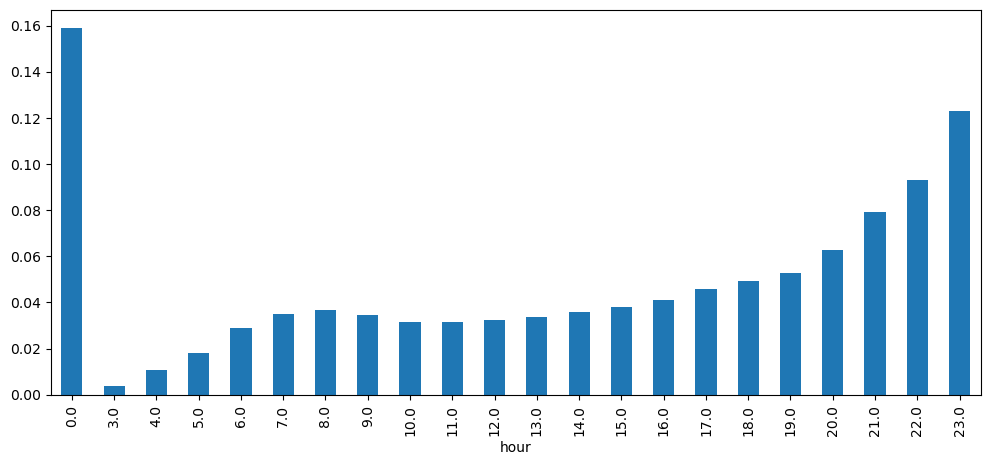

In [103]:
df_removed_NAN.groupby("hour")["is_delayed"].mean().plot(kind="bar", figsize=(12,5))

<Axes: >

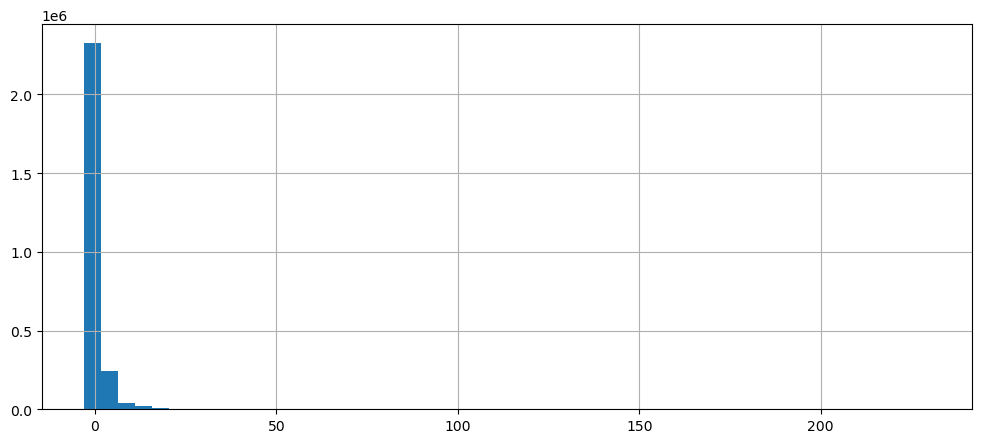

In [115]:
df_removed_NAN["arrival_delay"].hist(bins=50, figsize=(12,5))

In [123]:
delayed = df_removed_NAN[df_removed_NAN["arrival_delay"] >= 1]

In [125]:
delayed["arrival_delay"].value_counts().sort_index()

arrival_delay
1.0      235109
2.0      103126
3.0       59493
4.0       38263
5.0       25936
          ...  
180.0         1
192.0         1
193.0         1
224.0         1
230.0         1
Name: count, Length: 114, dtype: int64

<Axes: >

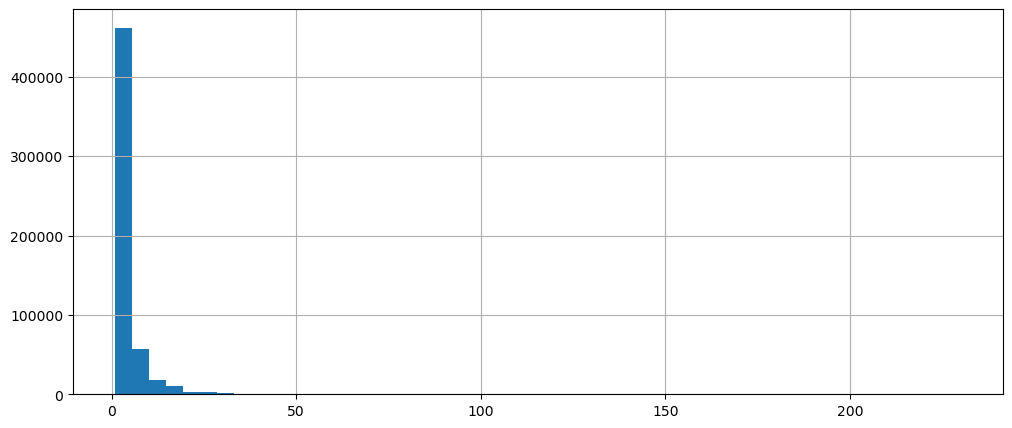

In [131]:
delayed["arrival_delay"].hist(bins=50, figsize=(12,5))

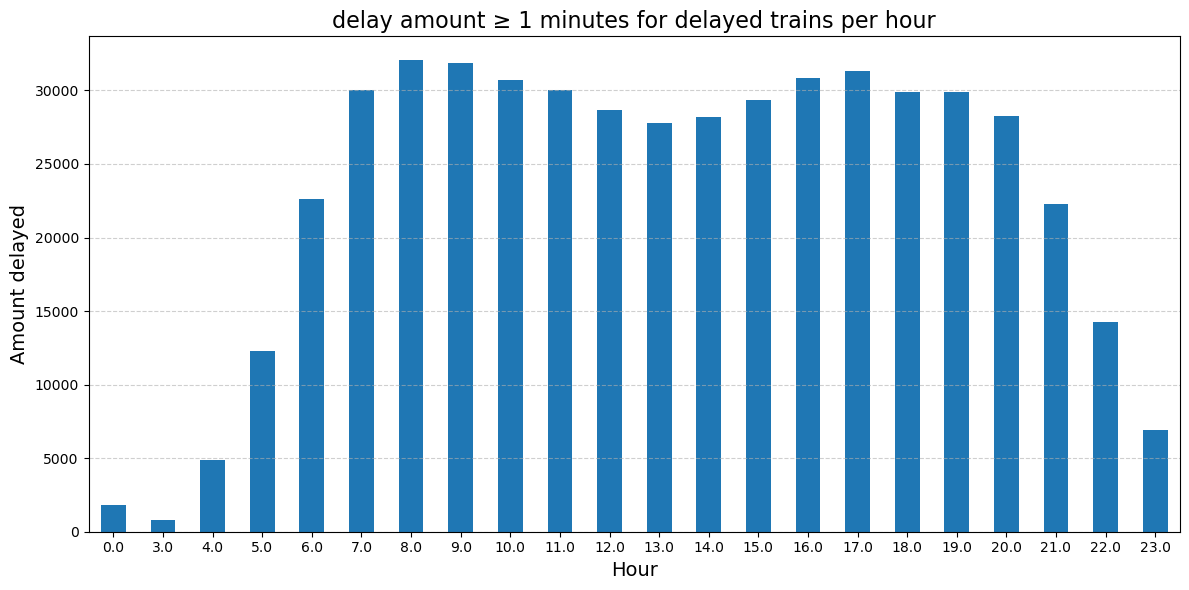

In [167]:
delayed.groupby("hour").size()

hour_counts = delayed.groupby("hour").size()

plt.figure(figsize=(12, 6))
hour_counts.plot(kind="bar")

plt.title("delay amount ≥ 1 minutes for delayed trains per hour", fontsize=16)
plt.xlabel("Hour", fontsize=14)
plt.ylabel("Amount delayed", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

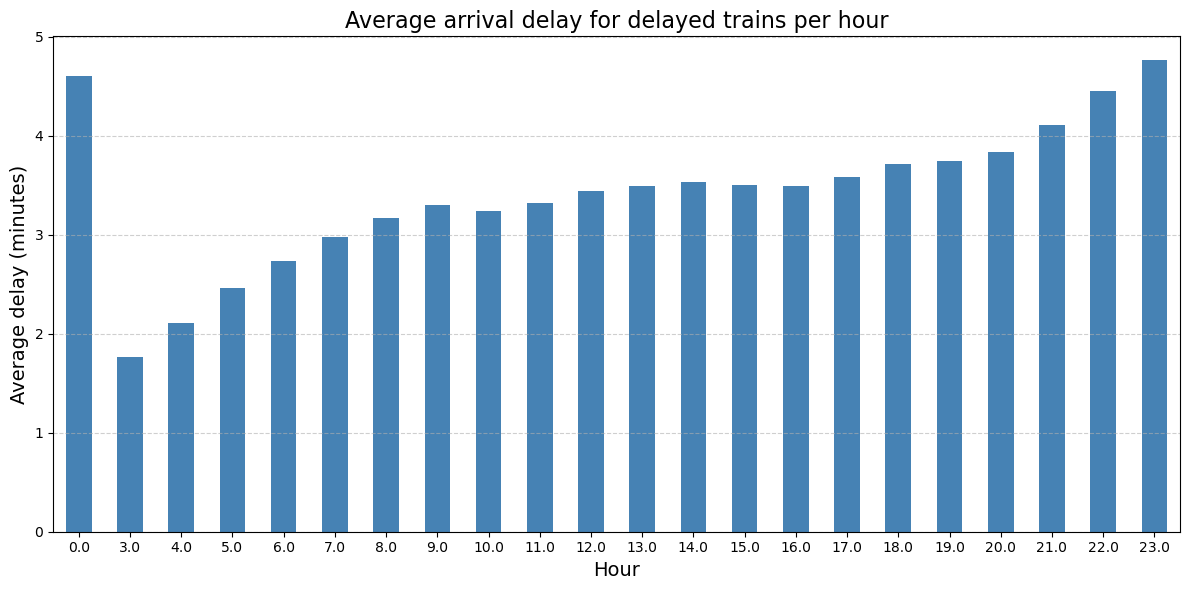

In [165]:
mean_delay_per_hour = delayed.groupby("hour")["arrival_delay"].mean()

plt.figure(figsize=(12, 6))
mean_delay_per_hour.plot(kind="bar", color="steelblue")

plt.title("Average arrival delay for delayed trains per hour", fontsize=16)
plt.xlabel("Hour", fontsize=14)
plt.ylabel("Average delay (minutes)", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

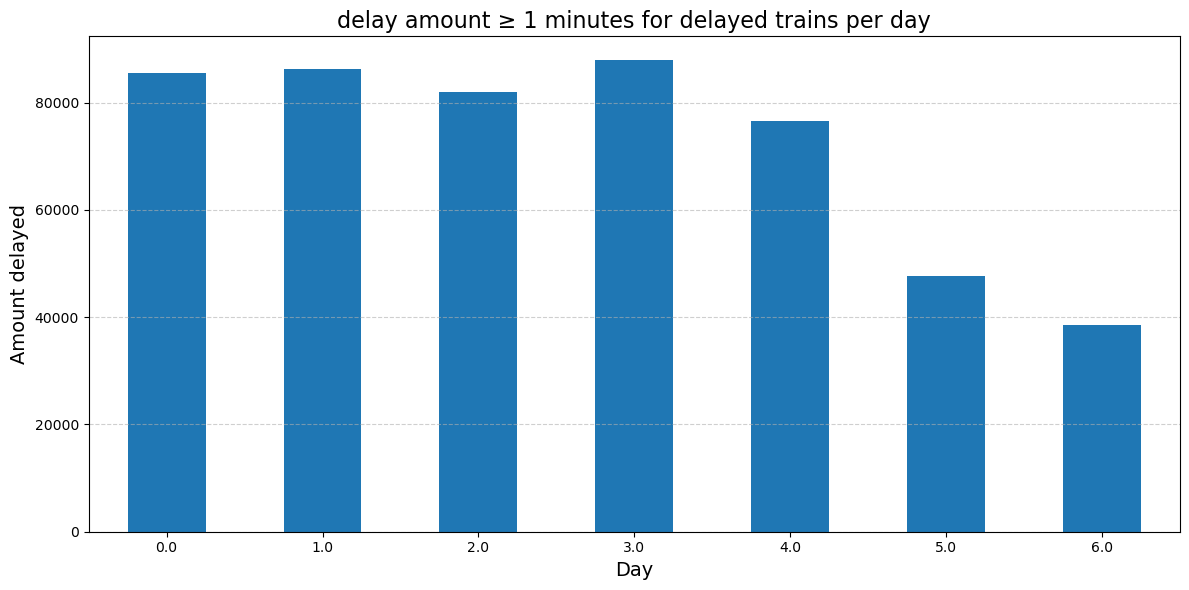

In [171]:
day_counts = delayed.groupby("day_of_week")["arrival_delay"].size()

plt.figure(figsize=(12, 6))
day_counts.plot(kind="bar")

plt.title("delay amount ≥ 1 minutes for delayed trains per day", fontsize=16)
plt.xlabel("Day", fontsize=14)
plt.ylabel("Amount delayed", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

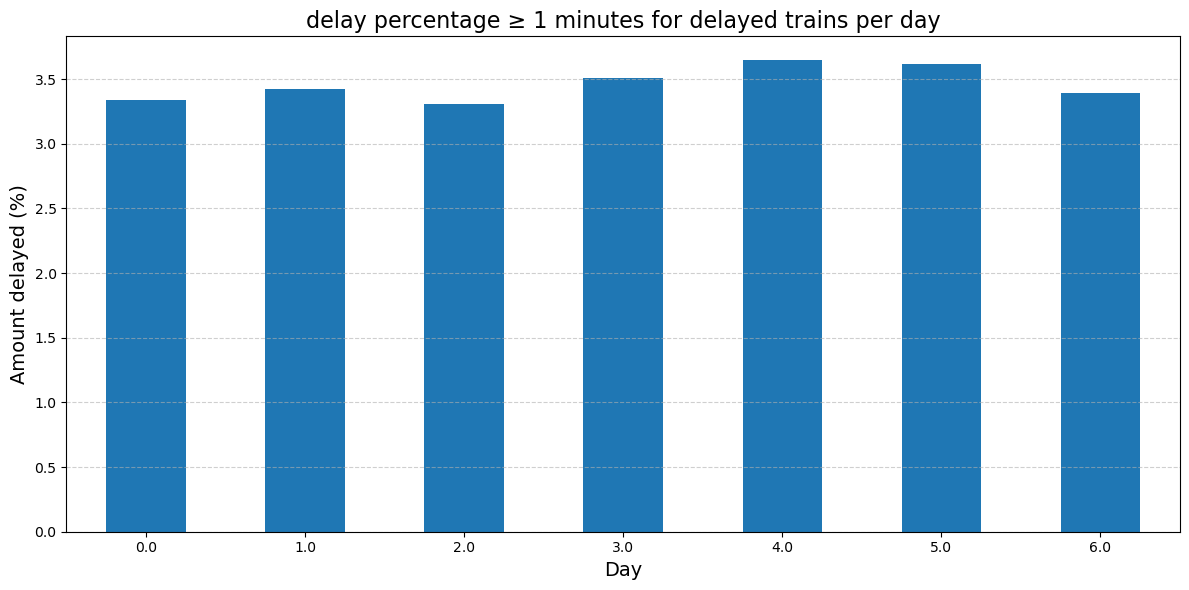

In [173]:
day_counts = delayed.groupby("day_of_week")["arrival_delay"].mean()

plt.figure(figsize=(12, 6))
day_counts.plot(kind="bar")

plt.title("delay percentage ≥ 1 minutes for delayed trains per day", fontsize=16)
plt.xlabel("Day", fontsize=14)
plt.ylabel("Amount delayed (%)", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

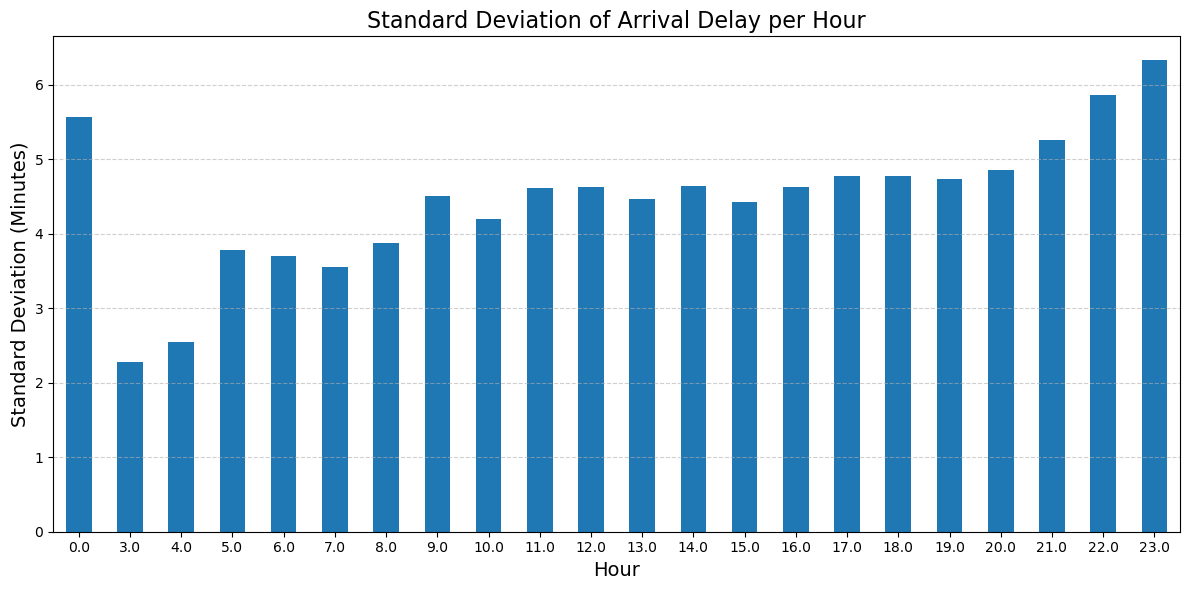

In [187]:
std_delay_per_hour = delayed.groupby("hour")["arrival_delay"].std()

plt.figure(figsize=(12, 6))
std_delay_per_hour.plot(kind="bar")

plt.title("Standard Deviation of Arrival Delay per Hour", fontsize=16)
plt.xlabel("Hour", fontsize=14)
plt.ylabel("Standard Deviation (Minutes)", fontsize=14)

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [189]:
std_delay_per_hour

hour
0.0     5.559593
3.0     2.281245
4.0     2.548774
5.0     3.786556
6.0     3.703350
7.0     3.558696
8.0     3.880148
9.0     4.507573
10.0    4.190456
11.0    4.614428
12.0    4.624912
13.0    4.471138
14.0    4.645493
15.0    4.418908
16.0    4.622691
17.0    4.769053
18.0    4.776183
19.0    4.727900
20.0    4.855256
21.0    5.251354
22.0    5.862740
23.0    6.331028
Name: arrival_delay, dtype: float64

<Axes: >

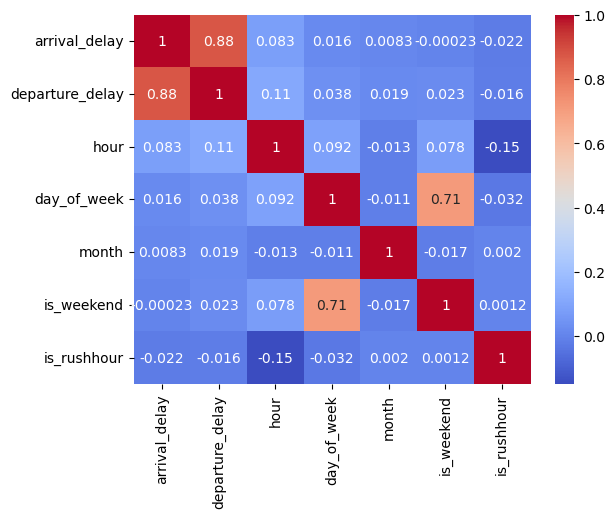

In [145]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ["arrival_delay", "departure_delay", "hour", "day_of_week", "month", "is_weekend", "is_rushhour"]

sns.heatmap(delayed[numeric_cols].corr(), annot=True, cmap="coolwarm")

In [147]:
delayed_5_minutes = df_removed_NAN[df_removed_NAN["arrival_delay"] >= 5]

In [151]:
delayed_5_minutes["arrival_delay"].value_counts().sort_index()

arrival_delay
5.0      25936
6.0      17646
7.0      12900
8.0      10406
9.0       8535
         ...  
180.0        1
192.0        1
193.0        1
224.0        1
230.0        1
Name: count, Length: 110, dtype: int64

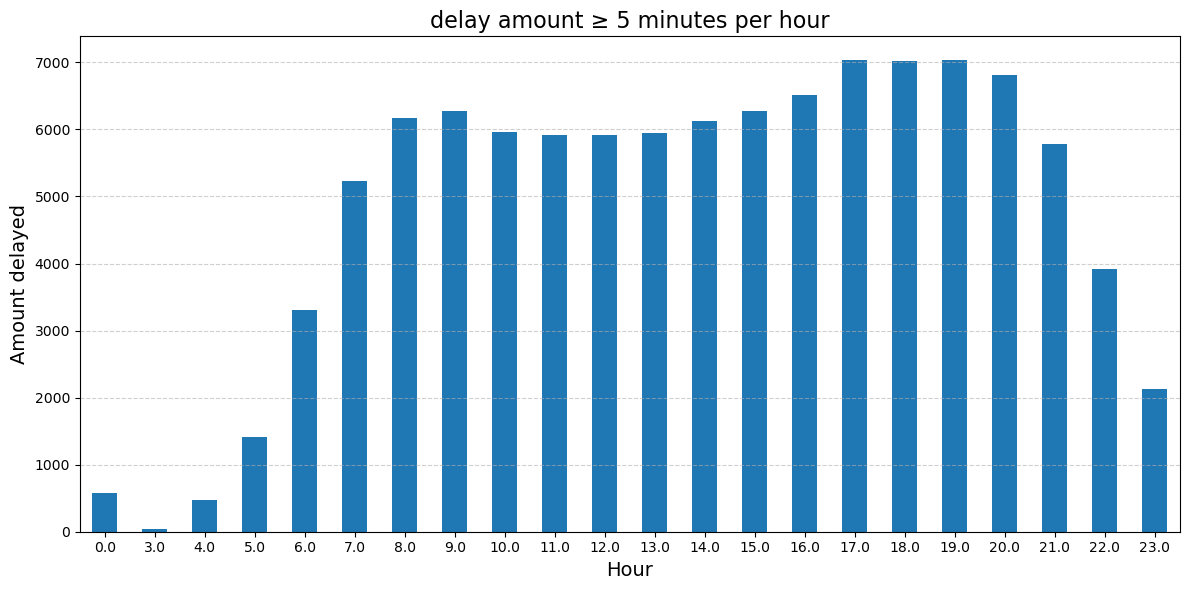

In [155]:
hour_counts = delayed_5_minutes.groupby("hour").size()

plt.figure(figsize=(12, 6))
hour_counts.plot(kind="bar")

plt.title("delay amount ≥ 5 minutes per hour", fontsize=16)
plt.xlabel("Hour", fontsize=14)
plt.ylabel("Amount delayed", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

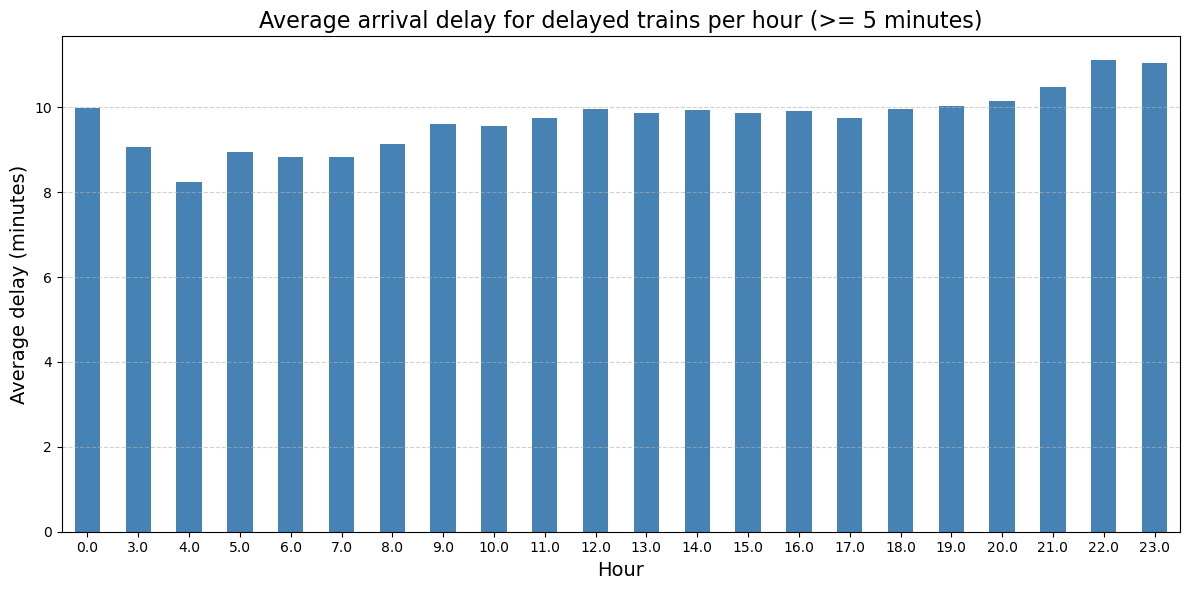

In [175]:
mean_delay_per_hour = delayed_5_minutes.groupby("hour")["arrival_delay"].mean()

plt.figure(figsize=(12, 6))
mean_delay_per_hour.plot(kind="bar", color="steelblue")

plt.title("Average arrival delay for delayed trains per hour (>= 5 minutes)", fontsize=16)
plt.xlabel("Hour", fontsize=14)
plt.ylabel("Average delay (minutes)", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

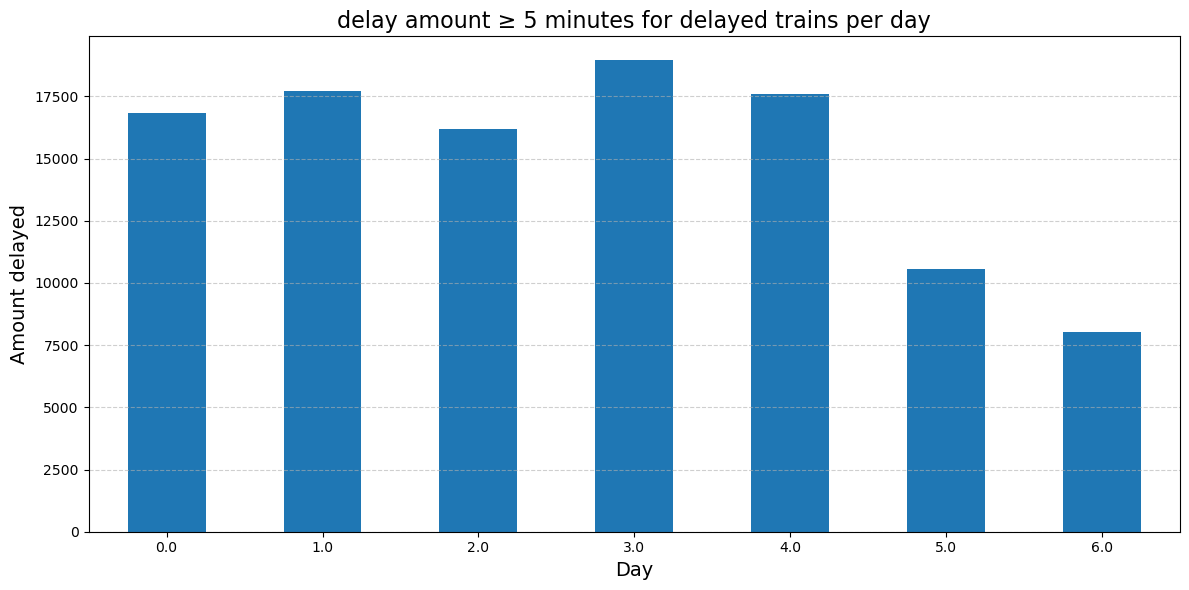

In [177]:
day_counts = delayed_5_minutes.groupby("day_of_week")["arrival_delay"].size()

plt.figure(figsize=(12, 6))
day_counts.plot(kind="bar")

plt.title("delay amount ≥ 5 minutes for delayed trains per day", fontsize=16)
plt.xlabel("Day", fontsize=14)
plt.ylabel("Amount delayed", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

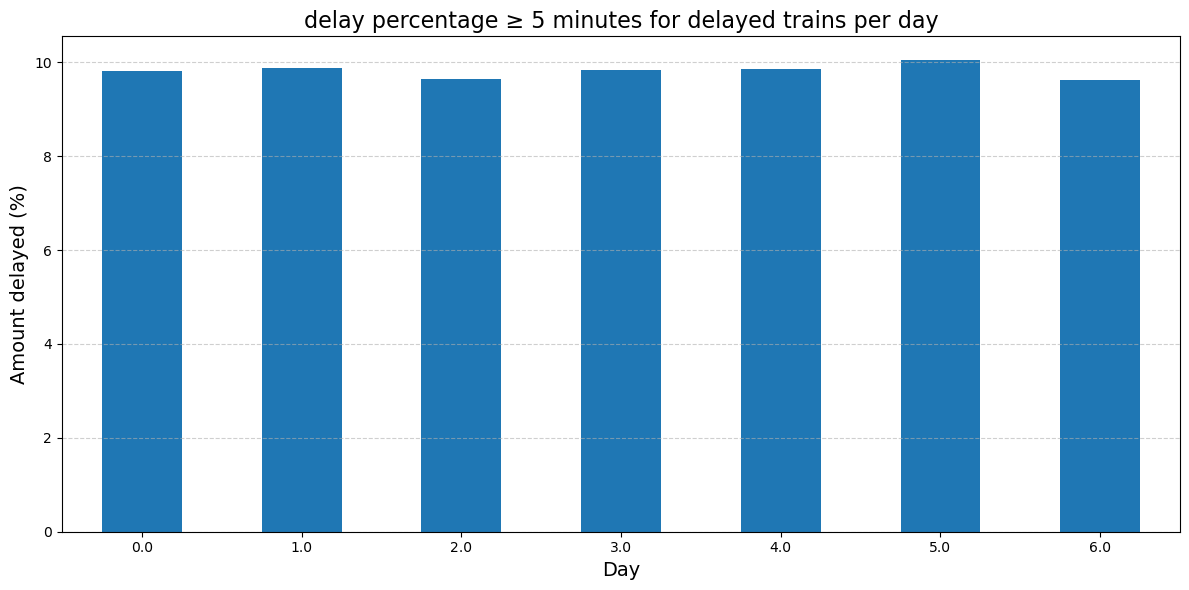

In [179]:
day_counts = delayed_5_minutes.groupby("day_of_week")["arrival_delay"].mean()

plt.figure(figsize=(12, 6))
day_counts.plot(kind="bar")

plt.title("delay percentage ≥ 5 minutes for delayed trains per day", fontsize=16)
plt.xlabel("Day", fontsize=14)
plt.ylabel("Amount delayed (%)", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<Axes: >

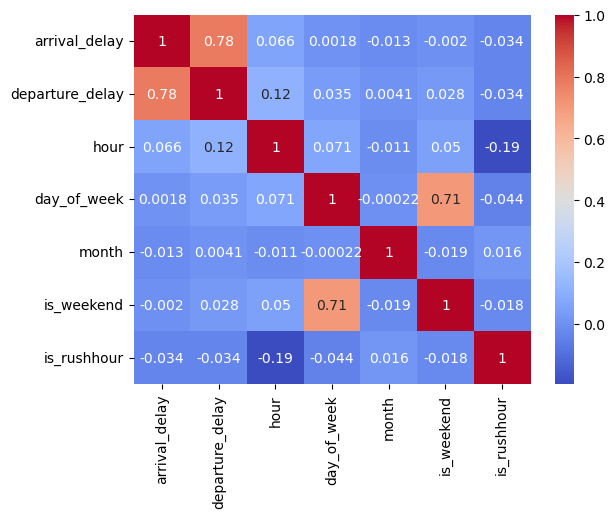

In [181]:
numeric_cols = ["arrival_delay", "departure_delay", "hour", "day_of_week", "month", "is_weekend", "is_rushhour"]

sns.heatmap(delayed_5_minutes[numeric_cols].corr(), annot=True, cmap="coolwarm")